In [15]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1  # make labels 0/1

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = CNN_LSTM()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# TRAIN 
epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

#  VALIDATION 
def evaluate(loader, name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds)
            all_labels.append(yb)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    print(f"\n{name} RESULTS")
    print("Accuracy:", (all_preds == all_labels).float().mean().item())
    print(confusion_matrix(all_labels.numpy(), all_preds.numpy()))
    print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Validate
evaluate(val_loader, "VALIDATION")

test_data = pd.read_csv('exoTest.csv')

X_test = test_data.drop('LABEL', axis=1).values
y_test = test_data['LABEL'].values - 1

X_test = scaler.transform(X_test)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

evaluate(test_loader, "TEST")

Epoch 1, Train Loss: 10.2743
Epoch 2, Train Loss: 5.7363
Epoch 3, Train Loss: 5.9956
Epoch 4, Train Loss: 5.8249
Epoch 5, Train Loss: 6.8681
Epoch 6, Train Loss: 6.0810
Epoch 7, Train Loss: 5.8424
Epoch 8, Train Loss: 5.9803
Epoch 9, Train Loss: 6.7865
Epoch 10, Train Loss: 5.8887


KeyboardInterrupt: 


VALIDATION RESULTS
Accuracy: 0.990176796913147
[[1008    3]
 [   7    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018


TEST RESULTS
Accuracy: 0.9894737005233765
[[564   1]
 [  5   0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       565
           1       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570



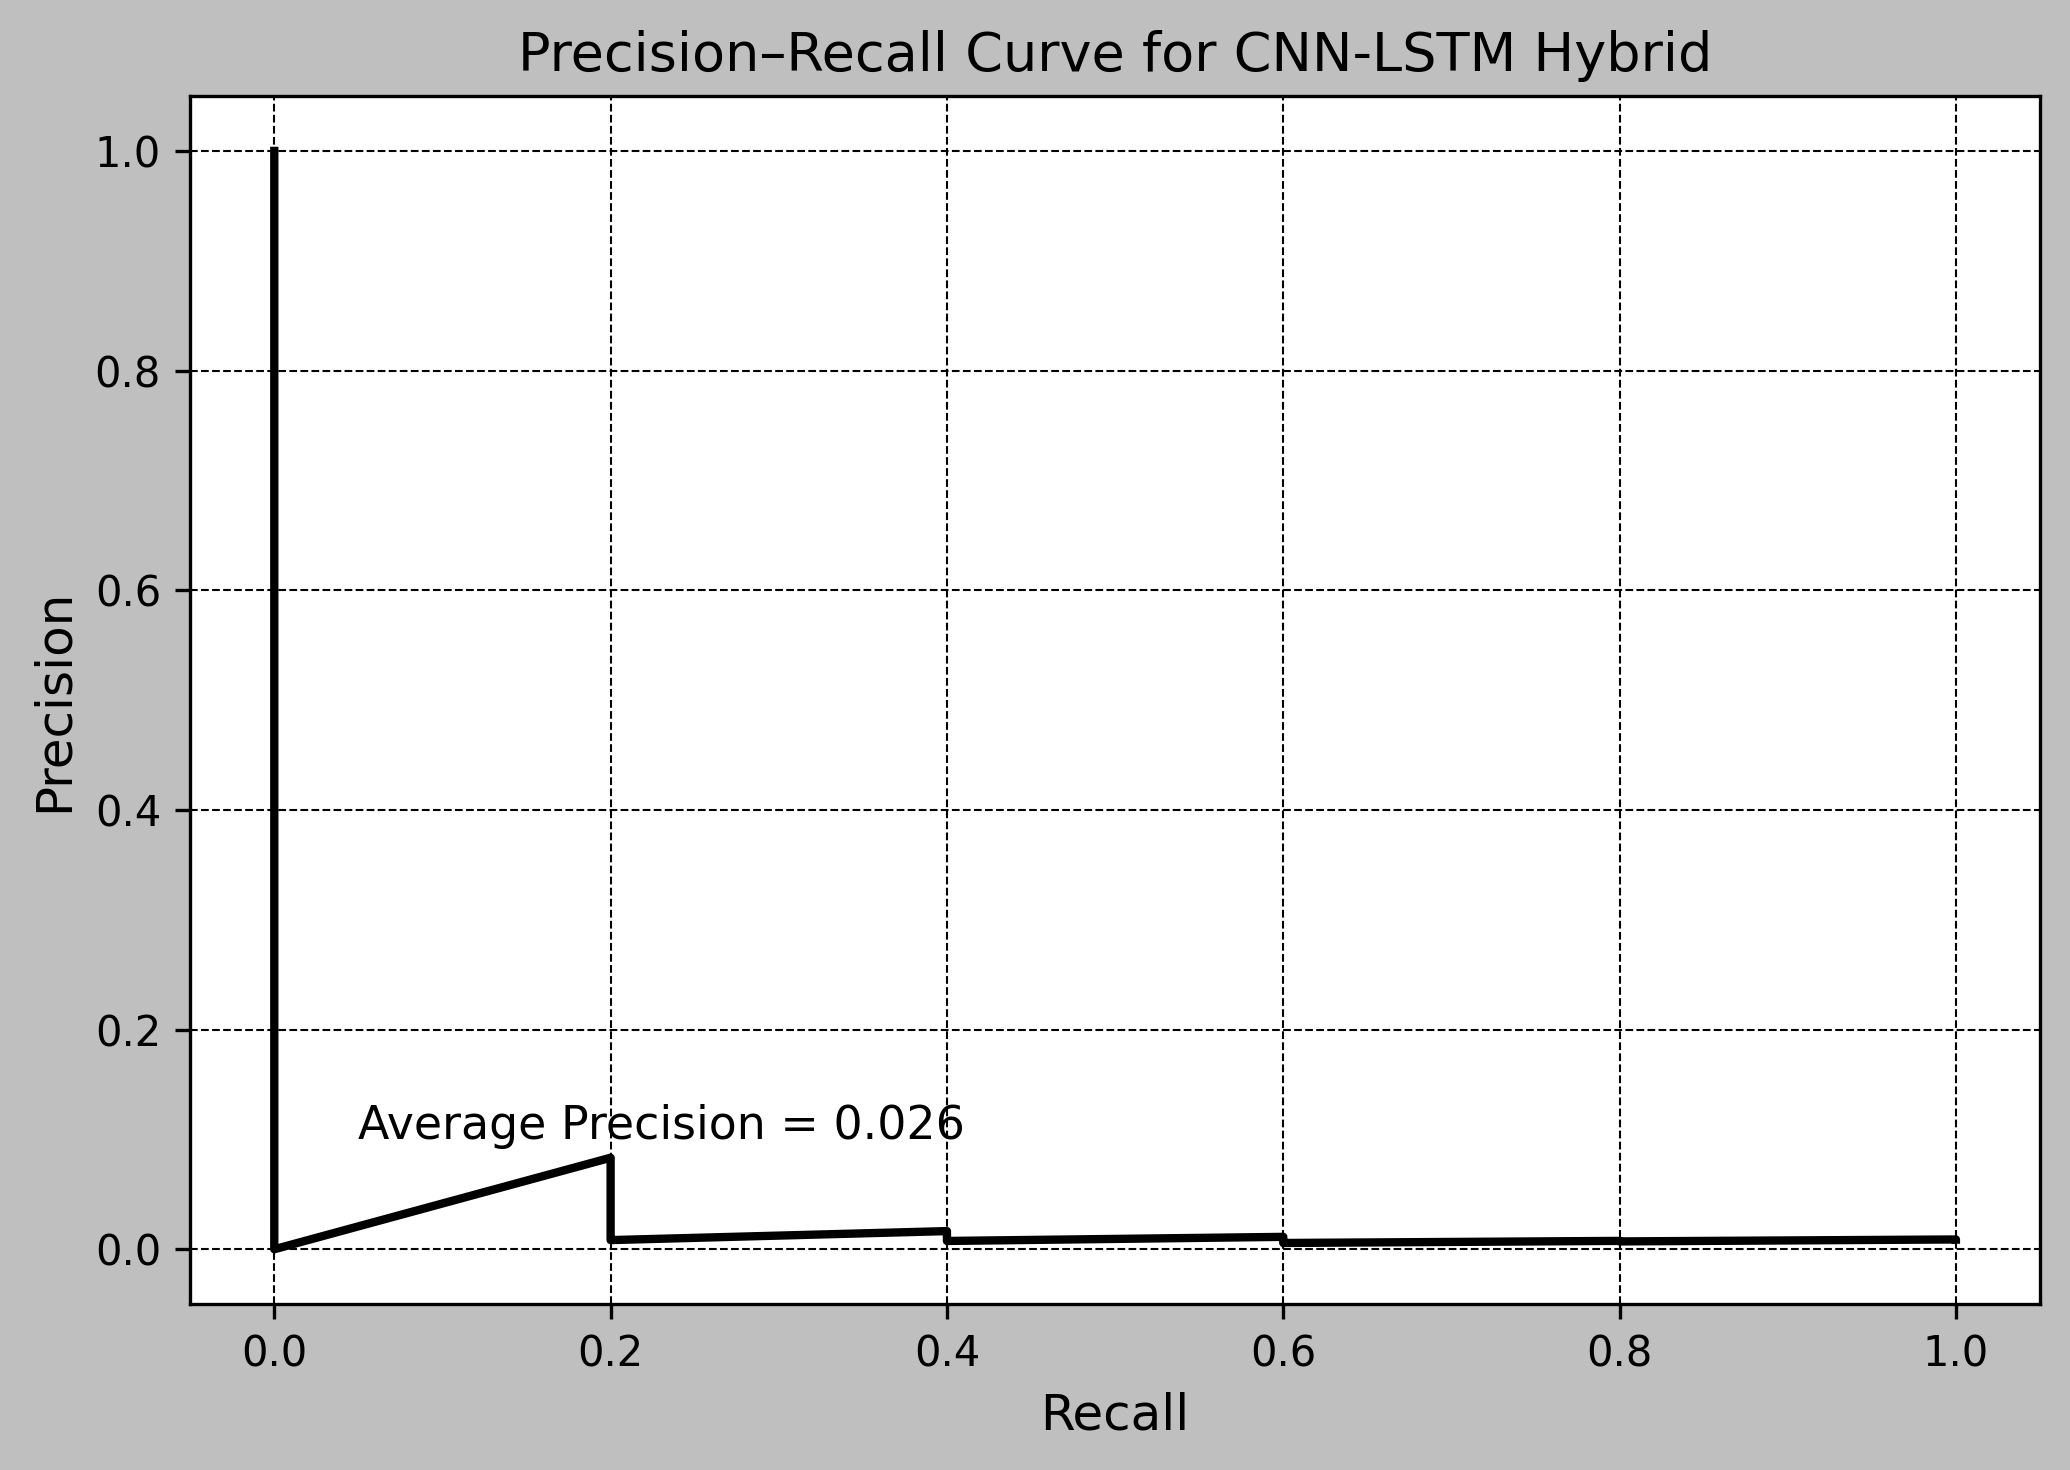

In [1]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1  # make labels 0/1

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = CNN_LSTM()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# TRAIN 
epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


#  VALIDATION 
def evaluate(loader, name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds)
            all_labels.append(yb)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    print(f"\n{name} RESULTS")
    print("Accuracy:", (all_preds == all_labels).float().mean().item())
    print(confusion_matrix(all_labels.numpy(), all_preds.numpy()))
    print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Validate
evaluate(val_loader, "VALIDATION")

test_data = pd.read_csv('exoTest.csv')

X_test = test_data.drop('LABEL', axis=1).values
y_test = test_data['LABEL'].values - 1

X_test = scaler.transform(X_test)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

evaluate(test_loader, "TEST")

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import torch

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)

        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

plt.style.use('grayscale')

plt.figure(figsize=(7,5), dpi=300)
plt.plot(recall, precision, linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision–Recall Curve for CNN-LSTM Hybrid', fontsize=13)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.text(
    0.05,
    0.1,
    f'Average Precision = {ap_score:.3f}',
    fontsize=11
)

plt.tight_layout()
plt.savefig('hybrid_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

Epoch 1, Train Loss: 82.9808
Epoch 2, Train Loss: 76.5346
Epoch 3, Train Loss: 65.4250
Epoch 4, Train Loss: 57.4578
Epoch 5, Train Loss: 51.7185
Epoch 6, Train Loss: 39.2981
Epoch 7, Train Loss: 31.4449
Epoch 8, Train Loss: 28.2417
Epoch 9, Train Loss: 17.5360
Epoch 10, Train Loss: 17.3926
Epoch 11, Train Loss: 20.1674
Epoch 12, Train Loss: 12.9256
Epoch 13, Train Loss: 12.0840
Epoch 14, Train Loss: 7.8418
Epoch 15, Train Loss: 6.7924

VALIDATION RESULTS
Accuracy: 0.6208251714706421
[[629 382]
 [  4   3]]
              precision    recall  f1-score   support

           0       0.99      0.62      0.77      1011
           1       0.01      0.43      0.02         7

    accuracy                           0.62      1018
   macro avg       0.50      0.53      0.39      1018
weighted avg       0.99      0.62      0.76      1018


TEST RESULTS
Accuracy: 0.6947368383407593
[[393 172]
 [  2   3]]
              precision    recall  f1-score   support

           0       0.99      0.70      0.

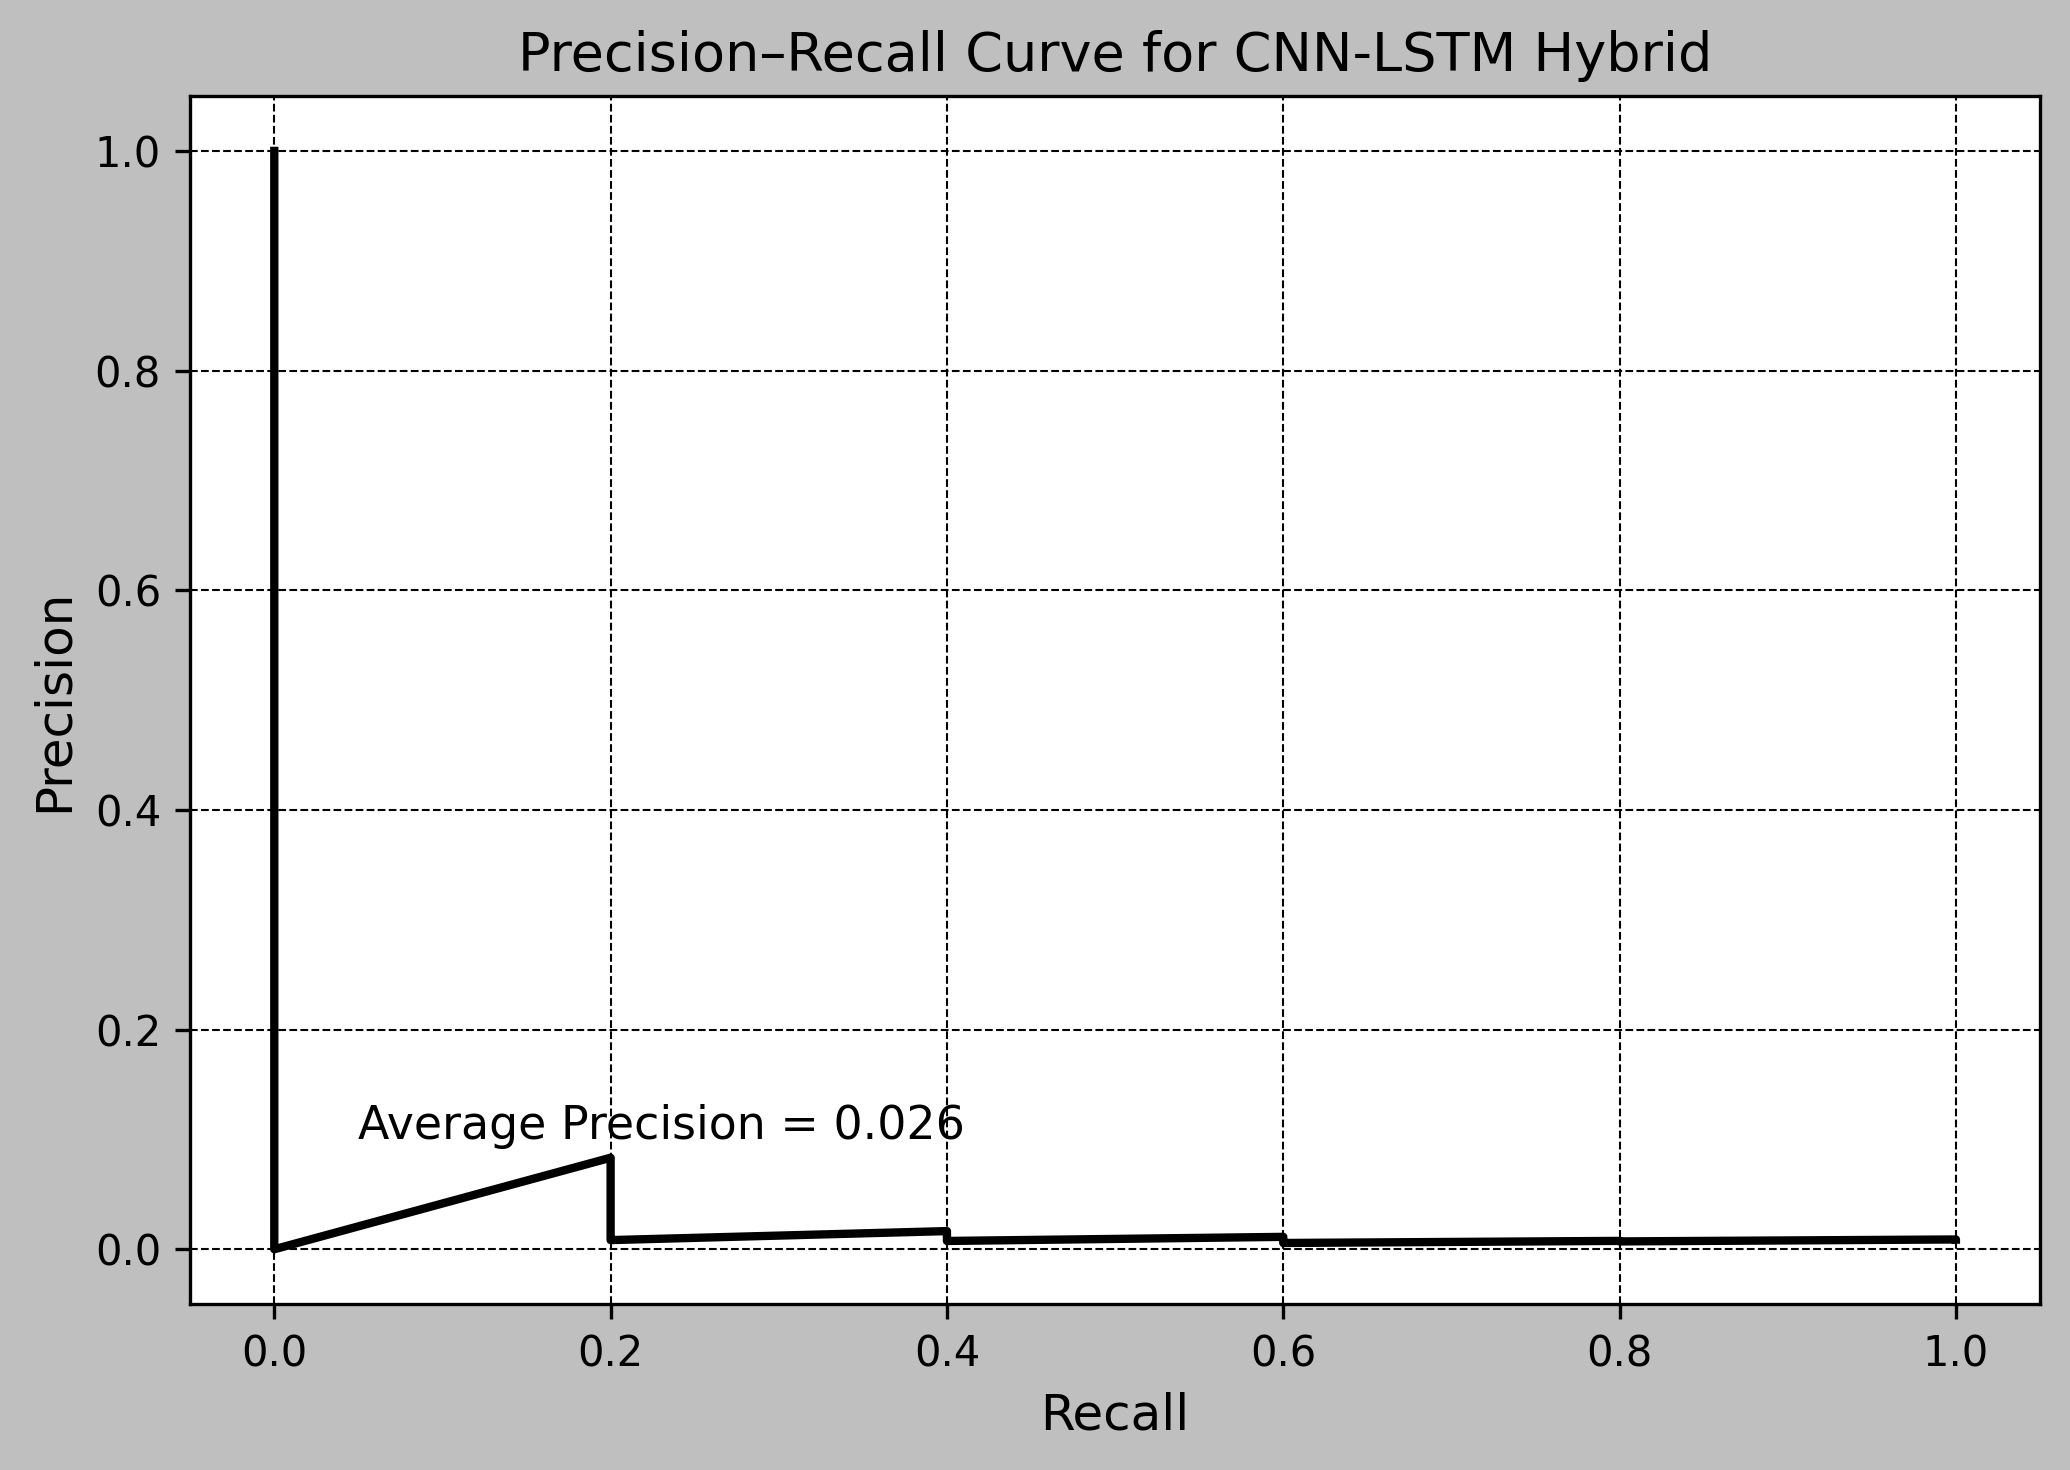

In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1  # make labels 0/1

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = CNN_LSTM()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# TRAIN 
epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

#  VALIDATION 
def evaluate(loader, name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds)
            all_labels.append(yb)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    print(f"\n{name} RESULTS")
    print("Accuracy:", (all_preds == all_labels).float().mean().item())
    print(confusion_matrix(all_labels.numpy(), all_preds.numpy()))
    print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Validate
evaluate(val_loader, "VALIDATION")

test_data = pd.read_csv('exoTest.csv')

X_test = test_data.drop('LABEL', axis=1).values
y_test = test_data['LABEL'].values - 1

X_test = scaler.transform(X_test)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

evaluate(test_loader, "TEST")
plt.style.use('grayscale')

plt.figure(figsize=(7,5), dpi=300)
plt.plot(recall, precision, linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision–Recall Curve for CNN-LSTM Hybrid', fontsize=13)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.text(
    0.05,
    0.1,
    f'Average Precision = {ap_score:.3f}',
    fontsize=11
)

plt.tight_layout()
plt.savefig('hybrid_pr_curve1.png', dpi=300, bbox_inches='tight')
plt.show()

Using device: cpu
Epoch 01 | Loss: 0.5133 | Val Accuracy: 0.9774
Epoch 02 | Loss: 0.5056 | Val Accuracy: 0.9263
Epoch 03 | Loss: 0.4913 | Val Accuracy: 0.9352
Epoch 04 | Loss: 0.4871 | Val Accuracy: 0.9450
Epoch 05 | Loss: 0.4739 | Val Accuracy: 0.9450
Epoch 06 | Loss: 0.4545 | Val Accuracy: 0.9558
Epoch 07 | Loss: 0.4431 | Val Accuracy: 0.9096
Epoch 08 | Loss: 0.4227 | Val Accuracy: 0.9499
Epoch 09 | Loss: 0.3833 | Val Accuracy: 0.9489
Epoch 10 | Loss: 0.3416 | Val Accuracy: 0.9411
Epoch 11 | Loss: 0.2847 | Val Accuracy: 0.9568
Epoch 12 | Loss: 0.2922 | Val Accuracy: 0.9597
Epoch 13 | Loss: 0.2402 | Val Accuracy: 0.9627
Epoch 14 | Loss: 0.2225 | Val Accuracy: 0.9637
Epoch 15 | Loss: 0.2017 | Val Accuracy: 0.9607
Epoch 16 | Loss: 0.1903 | Val Accuracy: 0.9587
Epoch 17 | Loss: 0.2002 | Val Accuracy: 0.9470
Epoch 18 | Loss: 0.2035 | Val Accuracy: 0.9666
Epoch 19 | Loss: 0.1483 | Val Accuracy: 0.9617
Epoch 20 | Loss: 0.1869 | Val Accuracy: 0.9587
Epoch 21 | Loss: 0.1813 | Val Accuracy: 0.

C:\Users\PC\AppData\Local\Temp\ipykernel_18864\3778547890.py:363: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_exonet.pth")



VALIDATION RESULTS
Accuracy: 0.9774066797642437

Confusion Matrix
[[995  16]
 [  7   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.98      1018
   macro avg       0.50      0.49      0.49      1018
weighted avg       0.99      0.98      0.98      1018



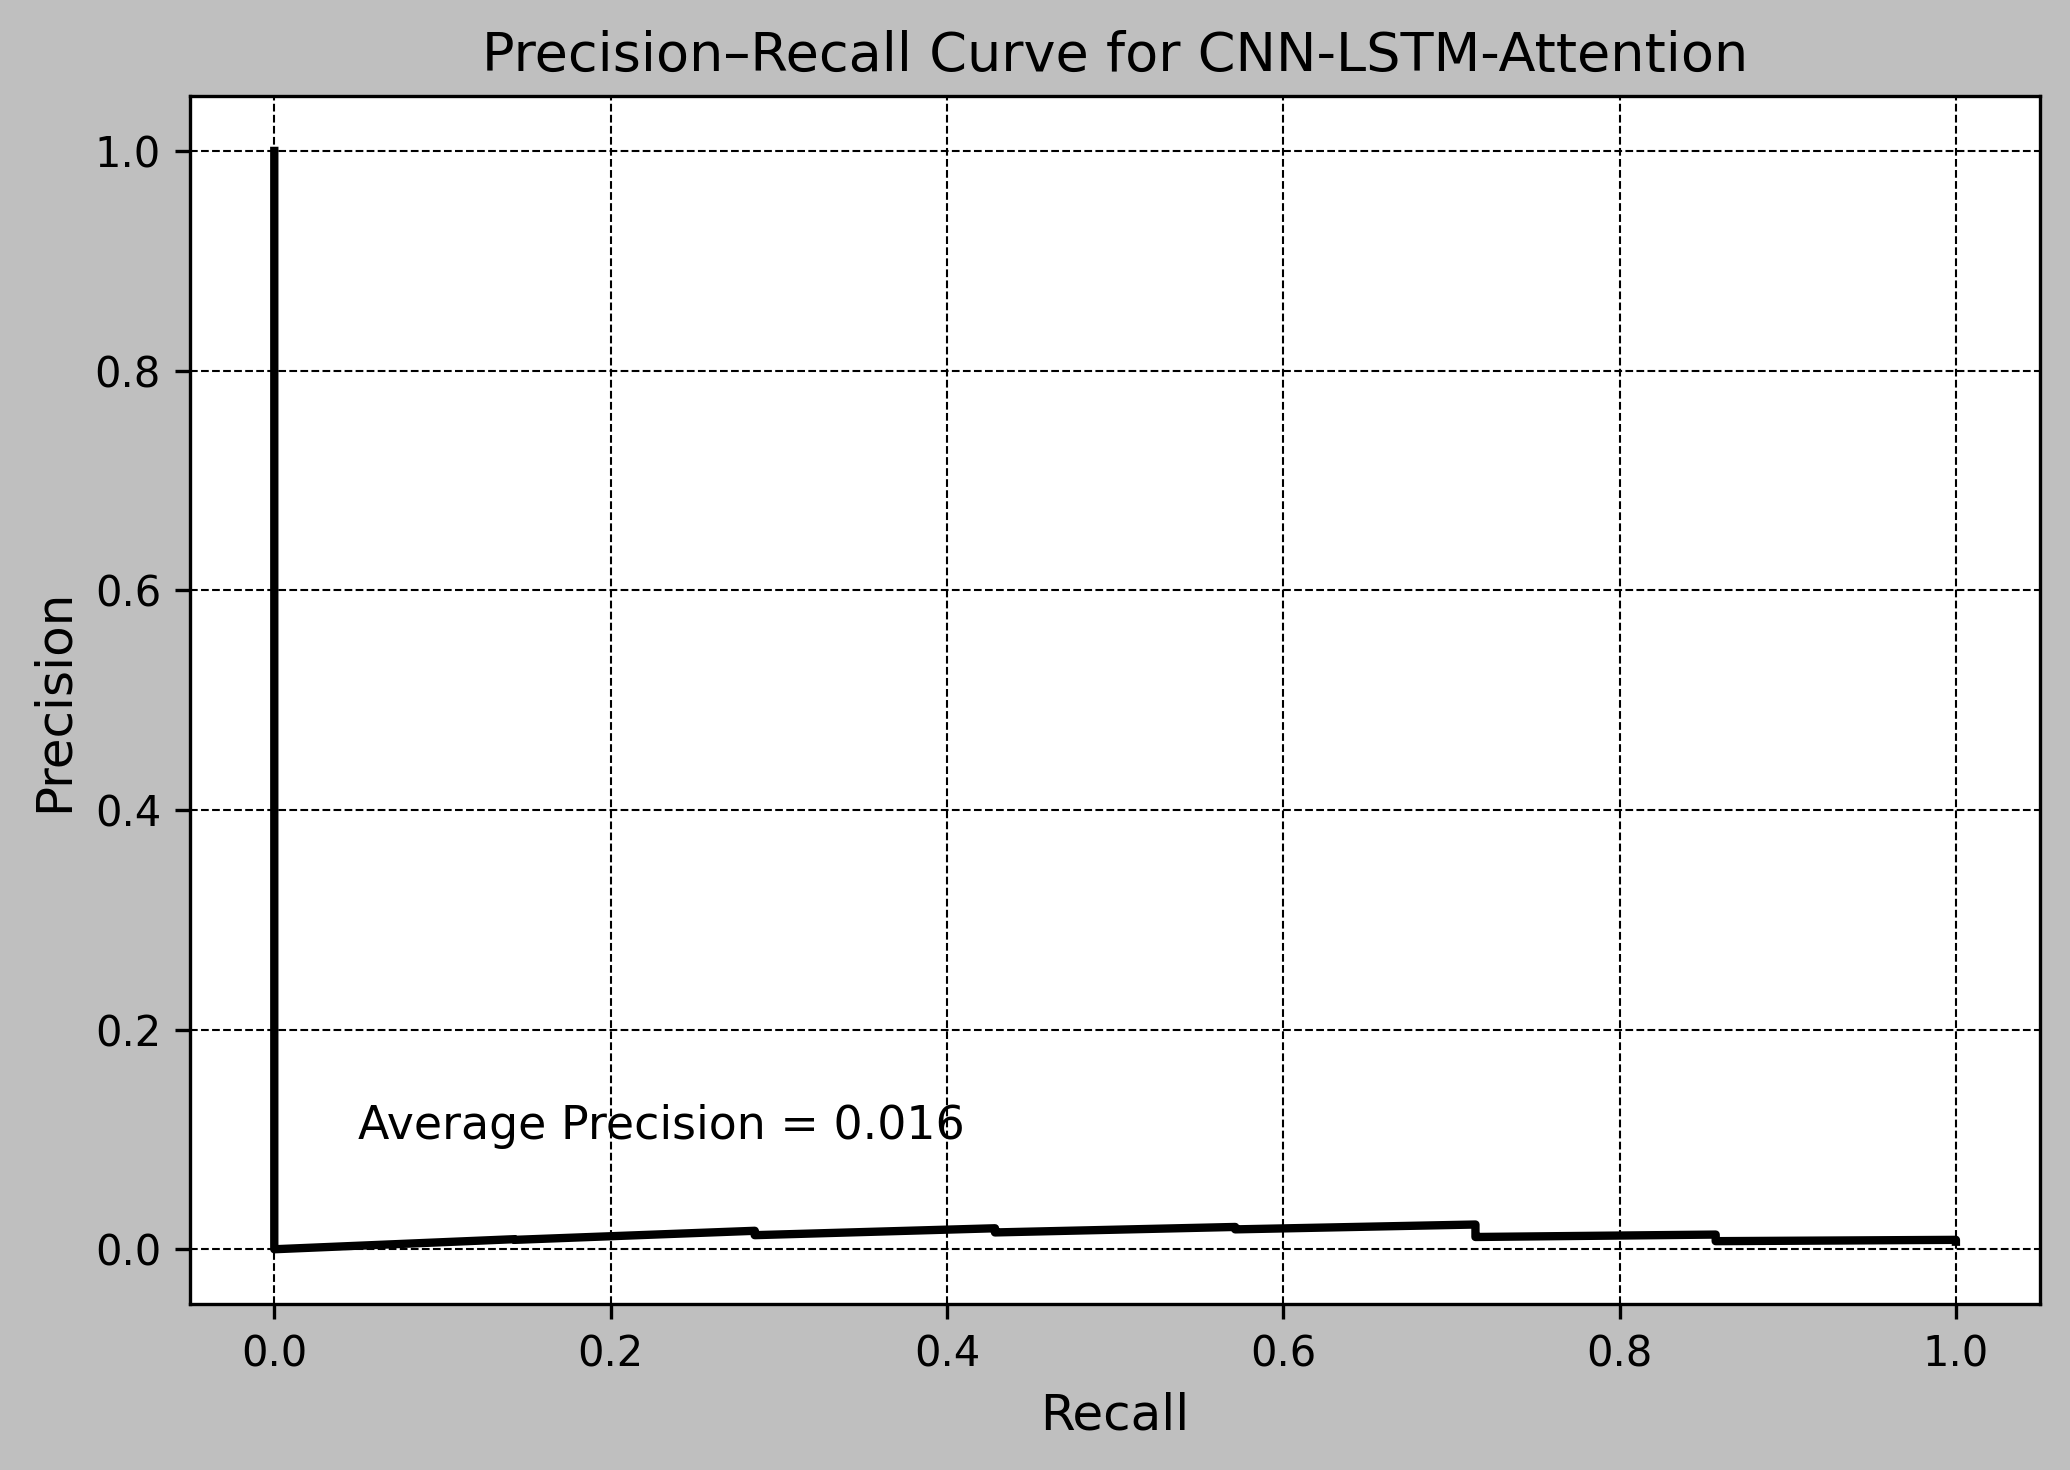

NameError: name 'test_loader' is not defined

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cpu")
print("Using device:", device)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv("exoTrain.csv")

X = data.drop("LABEL", axis=1).values
y = data["LABEL"].values - 1

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# NORMALIZATION
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# ============================================================
# TENSORS
# ============================================================

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

# ============================================================
# DATASETS
# ============================================================

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

# ============================================================
# BALANCED SAMPLING
# ============================================================

class_counts = torch.bincount(y_train)

class_weights = 1.0 / class_counts.float()

sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, alpha=2, gamma=2):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):

        ce_loss = self.ce(logits, targets)

        pt = torch.exp(-ce_loss)

        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

# ============================================================
# ATTENTION
# ============================================================

class Attention(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):

        weights = self.attn(x)

        weights = torch.softmax(weights, dim=1)

        context = torch.sum(weights * x, dim=1)

        return context

# ============================================================
# CNN + LSTM + ATTENTION
# ============================================================

class ExoNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ---------------- CNN ----------------

        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.3)
        )

        # ---------------- LSTM ----------------

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # ---------------- Attention ----------------

        self.attention = Attention(128)

        # ---------------- Classifier ----------------

        self.classifier = nn.Sequential(

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        x = self.cnn(x)

        x = x.permute(0, 2, 1)

        lstm_out, _ = self.lstm(x)

        context = self.attention(lstm_out)

        out = self.classifier(context)

        return out

# ============================================================
# MODEL
# ============================================================

model = ExoNet().to(device)

criterion = FocalLoss(alpha=3, gamma=2)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

# ============================================================
# TRAINING
# ============================================================

epochs = 25

train_losses = []
val_accuracies = []

best_acc = 0

for epoch in range(epochs):

    # ================= TRAIN =================

    model.train()

    running_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # ================= VALIDATION =================

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)

            outputs = model(xb)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(yb.numpy())

    acc = accuracy_score(all_labels, all_preds)

    val_accuracies.append(acc)

    scheduler.step(acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Accuracy: {acc:.4f}"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            "best_exonet.pth"
        )

# ============================================================
# FINAL EVALUATION
# ============================================================

model.load_state_dict(
    torch.load("best_exonet.pth")
)

model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for xb, yb in val_loader:

        xb = xb.to(device)

        outputs = model(xb)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_probs.extend(probs.cpu().numpy())

        all_labels.extend(yb.numpy())

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(all_labels, all_preds)

print("\nVALIDATION RESULTS")

print("Accuracy:", accuracy)

print("\nConfusion Matrix")

print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report")

print(classification_report(all_labels, all_preds))

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, _ = precision_recall_curve(
    all_labels,
    all_probs
)

ap_score = average_precision_score(
    all_labels,
    all_probs
)

# ============================================================
# PAPER-STYLE GRAPH
# ============================================================

plt.style.use('grayscale')

plt.figure(figsize=(7,5), dpi=300)

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel(
    'Recall',
    fontsize=12
)

plt.ylabel(
    'Precision',
    fontsize=12
)

plt.title(
    'Precision–Recall Curve for CNN-LSTM-Attention',
    fontsize=13
)

plt.grid(
    True,
    linestyle='--',
    linewidth=0.5
)

plt.text(
    0.05,
    0.1,
    f'Average Precision = {ap_score:.3f}',
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    'paper_style_pr_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

from sklearn.metrics import confusion_matrix, accuracy_score

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("Total samples:", cm.sum())
print("Accuracy:", accuracy_score(all_labels, all_preds))


NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler
)

device = torch.device("cpu")

train_df = pd.read_csv("exoTrain.csv")

X = train_df.drop("LABEL", axis=1).values
y = train_df["LABEL"].values - 1

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

class_counts = torch.bincount(y_train)

class_weights = 1.0 / class_counts.float()

sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):

        x = self.conv(x)

        x = x.permute(0, 2, 1)

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out
    
model = CNN_LSTM().to(device)

criterion = nn.CrossEntropyLoss(
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

best_acc = 0

for epoch in range(20):

    model.train()

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

    # validation

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)

            outputs = model(xb)

            pred = torch.argmax(outputs, dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(yb.numpy())

    acc = accuracy_score(labels, preds)

    print(
        f"Epoch {epoch+1} Validation Accuracy: {acc:.4f}"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            "best_cnn_lstm.pth"
        )

    test_df = pd.read_csv("exoTest.csv")

X_test = test_df.drop("LABEL", axis=1).values
y_test = test_df["LABEL"].values - 1

X_test = scaler.transform(X_test)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

print("Test Samples:", len(y_test))
print("Positives:", (y_test == 1).sum().item())
print("Negatives:", (y_test == 0).sum().item())

model.load_state_dict(
    torch.load("best_cnn_lstm.pth")
)

model.eval()

preds = []
labels = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        outputs = model(xb)

        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        labels.extend(yb.numpy())

cm = confusion_matrix(labels, preds)

print("\nCONFUSION MATRIX")
print(cm)

print("\nTOTAL =", cm.sum())

print(
    "\nACCURACY =",
    accuracy_score(labels, preds)
)

print(
    classification_report(
        labels,
        preds,
        digits=4
    )
)

Epoch 1 Validation Accuracy: 0.0069
Epoch 2 Validation Accuracy: 0.0069
Epoch 3 Validation Accuracy: 0.0069
Epoch 4 Validation Accuracy: 0.0069
Epoch 5 Validation Accuracy: 0.0069
Epoch 6 Validation Accuracy: 0.0069
Epoch 7 Validation Accuracy: 0.0069
Epoch 8 Validation Accuracy: 0.0177
Epoch 9 Validation Accuracy: 0.0177
Epoch 10 Validation Accuracy: 0.0216
Epoch 11 Validation Accuracy: 0.0216
Epoch 12 Validation Accuracy: 0.0187
Epoch 13 Validation Accuracy: 0.0236
Epoch 14 Validation Accuracy: 0.0226
Epoch 15 Validation Accuracy: 0.0285
Epoch 16 Validation Accuracy: 0.0196
Epoch 17 Validation Accuracy: 0.0246
Epoch 18 Validation Accuracy: 0.0491
Epoch 19 Validation Accuracy: 0.0147
Epoch 20 Validation Accuracy: 0.0157
Test Samples: 570
Positives: 5
Negatives: 565


C:\Users\PC\AppData\Local\Temp\ipykernel_16448\3409887867.py:222: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_cnn_lstm.pth")



CONFUSION MATRIX
[[ 13 552]
 [  1   4]]

TOTAL = 570

ACCURACY = 0.02982456140350877
              precision    recall  f1-score   support

           0     0.9286    0.0230    0.0449       565
           1     0.0072    0.8000    0.0143         5

    accuracy                         0.0298       570
   macro avg     0.4679    0.4115    0.0296       570
weighted avg     0.9205    0.0298    0.0446       570



In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler
)

device = torch.device("cpu")

train_df = pd.read_csv("exoTrain.csv")

X = train_df.drop("LABEL", axis=1).values
y = train_df["LABEL"].values - 1

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

class_counts = torch.bincount(y_train)

class_weights = 1.0 / class_counts.float()

sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):

        x = self.conv(x)

        x = x.permute(0, 2, 1)

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out
    
model = CNN_LSTM().to(device)

criterion = nn.CrossEntropyLoss(
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

best_acc = 0

for epoch in range(20):

    model.train()

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

    # validation

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)

            outputs = model(xb)

            pred = torch.argmax(outputs, dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(yb.numpy())

    acc = accuracy_score(labels, preds)

    print(
        f"Epoch {epoch+1} Validation Accuracy: {acc:.4f}"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            "best_cnn_lstm.pth"
        )

    test_df = pd.read_csv("exoTest.csv")

X_test = test_df.drop("LABEL", axis=1).values
y_test = test_df["LABEL"].values - 1

X_test = scaler.transform(X_test)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

print("Test Samples:", len(y_test))
print("Positives:", (y_test == 1).sum().item())
print("Negatives:", (y_test == 0).sum().item())

model.load_state_dict(
    torch.load("best_cnn_lstm.pth")
)

model.eval()

preds = []
labels = []

with torch.no_grad():

    all_probs = []

for xb, yb in test_loader:

    xb = xb.to(device)

    outputs = model(xb)

    probs = torch.softmax(outputs, dim=1)[:,1]

    all_probs.extend(probs.detach().cpu().numpy())

    labels.extend(yb.numpy())

import numpy as np
from sklearn.metrics import confusion_matrix

labels = np.array(labels)
all_probs = np.array(all_probs)

for threshold in [0.5,0.4,0.3,0.2,0.1]:

    preds = (all_probs >= threshold).astype(int)

    cm = confusion_matrix(labels, preds)

    print("\nThreshold =", threshold)
    print(cm)

cm = confusion_matrix(labels, preds)

print("\nCONFUSION MATRIX")
print(cm)

print("\nTOTAL =", cm.sum())

print(
    "\nACCURACY =",
    accuracy_score(labels, preds)
)

print(
    classification_report(
        labels,
        preds,
        digits=4
    )
)

Epoch 1 Validation Accuracy: 0.9745
Epoch 2 Validation Accuracy: 0.9862
Epoch 3 Validation Accuracy: 0.9725
Epoch 4 Validation Accuracy: 0.9666
Epoch 5 Validation Accuracy: 0.9352
Epoch 6 Validation Accuracy: 0.9361
Epoch 7 Validation Accuracy: 0.9420
Epoch 8 Validation Accuracy: 0.9627
Epoch 9 Validation Accuracy: 0.9676
Epoch 10 Validation Accuracy: 0.9538
Epoch 11 Validation Accuracy: 0.9843
Epoch 12 Validation Accuracy: 0.9204
Epoch 13 Validation Accuracy: 0.9656
Epoch 14 Validation Accuracy: 0.9637
Epoch 15 Validation Accuracy: 0.9597
Epoch 16 Validation Accuracy: 0.9528
Epoch 17 Validation Accuracy: 0.9686
Epoch 18 Validation Accuracy: 0.9725
Epoch 19 Validation Accuracy: 0.9617
Epoch 20 Validation Accuracy: 0.9794
Test Samples: 570
Positives: 5
Negatives: 565


C:\Users\PC\AppData\Local\Temp\ipykernel_16448\4268697275.py:221: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_cnn_lstm.pth")


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# Setup device: utilize GPU if available, otherwise CPU
device = torch.device("cpu")

# --- 1. Load & Preprocess Data ---
train_df = pd.read_csv("exoTrain.csv")
X = train_df.drop("LABEL", axis=1).values
# Assuming labels are 1-based (e.g., 1 and 2), shift to 0-based
y = train_df["LABEL"].values - 1  

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Add channel dimension for nn.Conv1d -> shape: (Batch, Channels, Features)
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# --- 2. Address Class Imbalance ---
class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 3. Model Architecture ---
class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # Calculate resulting sequence length after conv layers manually, or determine dynamically.
        # LSTM expects (batch, seq_len, input_size)
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        # Permute from (batch, features, seq_len) to (batch, seq_len, features) for LSTM
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        # Extract the last time step output for classification
        out = out[:, -1, :] 
        out = self.fc(out)
        return out

model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. Training Loop ---
best_acc = 0.0
for epoch in range(20):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    preds = []
    labels_list = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            outputs = model(xb)
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            labels_list.extend(yb.numpy())

    acc = accuracy_score(labels_list, preds)
    print(f"Epoch {epoch+1} Validation Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_cnn_lstm.pth")

# --- 5. Test Evaluation ---
test_df = pd.read_csv("exoTest.csv")
X_test = test_df.drop("LABEL", axis=1).values
y_test = test_df["LABEL"].values - 1

X_test = scaler.transform(X_test)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

print("\nTest Samples:", len(y_test))
print("Positives:", (y_test == 1).sum().item())
print("Negatives:", (y_test == 0).sum().item())

# Load best model
model.load_state_dict(torch.load("best_cnn_lstm.pth"))
model.eval()

all_probs = []
labels_list = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        labels_list.extend(yb.numpy())

labels_arr = np.array(labels_list)
all_probs_arr = np.array(all_probs)

# --- 6. Threshold Tuning & Metrics ---
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    preds = (all_probs_arr >= threshold).astype(int)
    cm = confusion_matrix(labels_arr, preds)
    
    print(f"\n{'='*20}")
    print(f"Threshold = {threshold}")
    print(f"{'='*20}")
    print("CONFUSION MATRIX:")
    print(cm)
    print("TOTAL =", cm.sum())
    print("ACCURACY =", accuracy_score(labels_arr, preds))
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(labels_arr, preds, digits=4))


Epoch 1 Validation Accuracy: 0.9794
Epoch 2 Validation Accuracy: 0.9391
Epoch 3 Validation Accuracy: 0.9548
Epoch 4 Validation Accuracy: 0.9804
Epoch 5 Validation Accuracy: 0.9902
Epoch 6 Validation Accuracy: 0.9921
Epoch 7 Validation Accuracy: 0.9921
Epoch 8 Validation Accuracy: 0.9902
Epoch 9 Validation Accuracy: 0.9921
Epoch 10 Validation Accuracy: 0.9882
Epoch 11 Validation Accuracy: 0.9715
Epoch 12 Validation Accuracy: 0.9921
Epoch 13 Validation Accuracy: 0.9931
Epoch 14 Validation Accuracy: 0.9912
Epoch 15 Validation Accuracy: 0.9931
Epoch 16 Validation Accuracy: 0.9912
Epoch 17 Validation Accuracy: 0.9853
Epoch 18 Validation Accuracy: 0.9853
Epoch 19 Validation Accuracy: 0.9892
Epoch 20 Validation Accuracy: 0.9931

Test Samples: 570
Positives: 5
Negatives: 565


C:\Users\PC\AppData\Local\Temp\ipykernel_16448\3516264751.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cnn_lstm.pth"))



Threshold = 0.5
CONFUSION MATRIX:
[[564   1]
 [  5   0]]
TOTAL = 570
ACCURACY = 0.9894736842105263

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.9912    0.9982    0.9947       565
           1     0.0000    0.0000    0.0000         5

    accuracy                         0.9895       570
   macro avg     0.4956    0.4991    0.4974       570
weighted avg     0.9825    0.9895    0.9860       570


Threshold = 0.4
CONFUSION MATRIX:
[[ 23 542]
 [  1   4]]
TOTAL = 570
ACCURACY = 0.04736842105263158

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.9583    0.0407    0.0781       565
           1     0.0073    0.8000    0.0145         5

    accuracy                         0.0474       570
   macro avg     0.4828    0.4204    0.0463       570
weighted avg     0.9500    0.0474    0.0775       570


Threshold = 0.3
CONFUSION MATRIX:
[[ 23 542]
 [  1   4]]
TOTAL = 570
ACCURACY = 0.04736842105263